### **tf dataset flowers(5종 꽃 이미지)으로 전이학습(MobileNet V2) + 미세조정**

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

(train_ds, val_ds), ds_info = tfds.load(
    'tf_flowers',
    split = ['train[:80%]', 'train[80%:]'],
    shuffle_files = True,
    as_supervised = True, # tuple 형태로 반환
    with_info = True
)

for image, label in train_ds.take(1):
  print(type(image), type(label))

print(ds_info.features['label'].names) # ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [2]:
# 전처리
# 이미지는 정규화가 잘 나오지만 표준화가 더 잘 나올때도 있어서 둘다 진행해보는게 좋다.

IMG_SIZE = (160, 160)
BATCH_SIZE = 32 # 32개씩 순차적으로 CPU/GPU에 순차적으로 올려서 진행하겠다

def preprocessFunc(image, label):
  # img 사이즈 통일
  image = tf.image.resize(image, IMG_SIZE)
  # 정규화
  image = tf.cast(image, tf.float32) / 255.0
  return image, label


train_ds = train_ds.map(preprocessFunc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocessFunc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Base Model(백본모델) 불러오기
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3, ), # (160, 160, 3) 튜플로 줘야함!
    include_top = False,
    weights = 'imagenet'
)
base_model.trainalbe = False

# 내가 사용할 Model
model = tf.keras.Sequential([
    base_model, # 학습에 참여 없이 특징 추출기 역할만 함.
    layers.GlobalAveragePooling2D(),
    layers.Dense(units=128, activation = 'relu'),
    layers.Dense(units=ds_info.features['label'].num_classes, activation = 'softmax')
])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

print(base_model.summary())
print(model.summary())

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 2,388,485 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [3]:
model.fit(
    train_ds, validation_data = val_ds, epochs = 5, verbose = 1)

loss, acc = model.evaluate(val_ds)
print(f'loss : {loss:.4f}, acc : {acc:.4f}')

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 171s 944ms/step - accuracy: 0.7864 - loss: 0.6082 - val_accuracy: 0.6894 - val_loss: 3.8732
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.8866 - loss: 0.3306 - val_accuracy: 0.5218 - val_loss: 8.8058
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9026 - loss: 0.2911 - val_accuracy: 0.4605 - val_loss: 7.8575
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9329 - loss: 0.2090 - val_accuracy: 0.6144 - val_loss: 6.2343
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.9414 - loss: 0.1649 - val_accuracy: 0.6703 - val_loss: 3.7113
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6703 - loss: 3.7113
loss : 3.7113, acc : 0.6703


In [4]:
# 다음단계 - 미세조정(Fine Tunning)
# base model의 일부 layer를 학습에 참여
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-6), # 학습률 낮추기!
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
print('Fine Tunning 시작')

model.fit(
    train_ds, validation_data = val_ds, epochs = 5, verbose = 1)

loss, acc = model.evaluate(val_ds)
print(f'Fine Tunning loss : {loss:.4f}, acc : {acc:.4f}')

Fine Tunning 시작
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 65s 376ms/step - accuracy: 0.9261 - loss: 0.2720 - val_accuracy: 0.7003 - val_loss: 3.2014
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9281 - loss: 0.2584 - val_accuracy: 0.7316 - val_loss: 2.7147
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9298 - loss: 0.2460 - val_accuracy: 0.7520 - val_loss: 2.2915
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9288 - loss: 0.2460 - val_accuracy: 0.7725 - val_loss: 1.9400
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.9339 - loss: 0.2243 - val_accuracy: 0.8052 - val_loss: 1.6442
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8052 - loss: 1.6442
Fine Tunning loss : 1.6442, acc : 0.8052


In [12]:
# 검증 데이터셋에서 이미지 1개 추출후 예측하기
for image, label in val_ds.take(1):
  sample_image = image
  sample_label = label
  break

pred_probs = model.predict(sample_image)
print(pred_probs)

pred_classes  = tf.argmax(pred_probs, axis = 1)
print(pred_classes)

print(sample_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
[[3.10063548e-08 6.68514247e-07 1.15301336e-04 1.05931252e-01
  8.93952787e-01]
 [1.05155014e-13 2.77540550e-13 1.00000000e+00 4.43477008e-14
  9.62217805e-11]
 [2.16670628e-07 9.04188073e-06 9.97564673e-01 2.96781909e-05
  2.39631347e-03]
 [2.26825611e-12 2.08650412e-13 1.00000000e+00 1.02282437e-15
  8.44400179e-13]
 [6.52657836e-05 9.99934554e-01 1.21855681e-08 1.75720261e-09
  6.11091693e-08]
 [3.57784302e-05 9.99642015e-01 2.41445363e-04 7.22991942e-08
  8.06365570e-05]
 [4.21041674e-10 1.00000000e+00 2.25138380e-10 1.98992467e-08
  2.08185205e-10]
 [1.14343200e-13 2.61788979e-10 1.00000000e+00 2.27453037e-15
  2.37994668e-09]
 [1.11232046e-09 2.47071679e-08 7.53027141e-10 1.00000000e+00
  1.30469013e-13]
 [4.33986874e-11 2.31752551e-11 5.98971556e-13 1.00000000e+00
  1.52306011e-14]
 [2.76832134e-06 6.77731261e-03 5.78758001e-01 1.13184949e-04
  4.14348692e-01]
 [2.14216977e-09 5.90211886e-04 7.75375383e-07 9.99408960e-01
  4.85155909e-11]
 [2.

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
[00] pred : 4 (roses), actual : 4 (roses)
[01] pred : 2 (tulips), actual : 2 (tulips)
[02] pred : 2 (tulips), actual : 2 (tulips)
[03] pred : 2 (tulips), actual : 2 (tulips)
[04] pred : 1 (daisy), actual : 1 (daisy)
[05] pred : 1 (daisy), actual : 1 (daisy)
[06] pred : 1 (daisy), actual : 1 (daisy)
[07] pred : 2 (tulips), actual : 2 (tulips)
[08] pred : 3 (sunflowers), actual : 3 (sunflowers)
[09] pred : 3 (sunflowers), actual : 3 (sunflowers)
[10] pred : 2 (tulips), actual : 4 (roses)
[11] pred : 3 (sunflowers), actual : 3 (sunflowers)
[12] pred : 1 (daisy), actual : 3 (sunflowers)
[13] pred : 2 (tulips), actual : 2 (tulips)
[14] pred : 2 (tulips), actual : 2 (tulips)
[15] pred : 0 (dandelion), actual : 0 (dandelion)
[16] pred : 2 (tulips), actual : 2 (tulips)
[17] pred : 0 (dandelion), actual : 0 (dandelion)
[18] pred : 3 (sunflowers), actual : 3 (sunflowers)
[19] pred : 0 (dandelion), actual : 0 (dandelion)
[20] pred : 2 (tulip

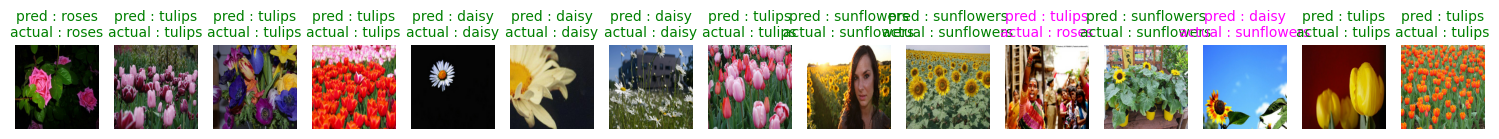

In [17]:
# 클래스 이름 얻기
class_names = ds_info.features['label'].names
print(class_names)

# 예측값과 실제값 출력
for i in range(len(sample_image)):
  predict_index = int(pred_classes[i])
  actual_index = int(sample_label[i])

  predict_name = class_names[predict_index]
  actual_name = class_names[actual_index]

  print(f'[{i:02}] pred : {predict_index} ({predict_name}), actual : {actual_index} ({actual_name})')

# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
for i in range(15):
  plt.subplot(1, 15, i+1)
  plt.imshow(sample_image[i])

  predicted_label = class_names[pred_classes[i]]
  actual_label = class_names[sample_label[i]]

  color = 'green' if predicted_label == actual_label else 'magenta'
  plt.title(f'pred : {predicted_label}\nactual : {actual_label}', color = color, fontsize=10)
  plt.axis('off')
plt.tight_layout()
plt.show()
